# PYPL-like анализ популярности языков программирования через Yandex Wordstat

В этом ноутбуке проводится анализ уже загруженных данных из Yandex Wordstat.

Ноутбук не обращается к API. Сначала нужно запустить `python load_wordstat.py`, затем `python main.py`, а после этого открыть и выполнить этот ноутбук.

## 1. Импорт библиотек

Подключаем библиотеки для работы с таблицами, датами и графиками.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## 2. Пути к файлам проекта

Указываем пути к CSV-файлам и папке для изображений.

In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"

RAW_DATA_PATH = DATA_DIR / "wordstat_dynamics_raw.csv"
MONTHLY_INDEX_PATH = DATA_DIR / "wordstat_monthly_index.csv"
LATEST_RANKING_PATH = DATA_DIR / "wordstat_latest_ranking.csv"

RAW_DATA_PATH, MONTHLY_INDEX_PATH, LATEST_RANKING_PATH

(PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_dynamics_raw.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_monthly_index.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_latest_ranking.csv'))

## 3. Загрузка сырых данных Wordstat

Файл `wordstat_dynamics_raw.csv` содержит помесячную динамику tutorial-запросов по выбранным языкам.

In [3]:
raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df["date"] = pd.to_datetime(raw_df["date"])
raw_df.head()

,language,phrase,date,count,share,period,from_date,to_date,devices
0,Python,python tutorial,2018-01-01 00:00:00+00:00,299,0.000004,monthly,2018-01-01,2026-04-30,all
1,Python,python tutorial,2018-02-01 00:00:00+00:00,435,0.000006,monthly,2018-01-01,2026-04-30,all
2,Python,python tutorial,2018-03-01 00:00:00+00:00,435,0.000005,monthly,2018-01-01,2026-04-30,all
3,Python,python tutorial,2018-04-01 00:00:00+00:00,465,0.000006,monthly,2018-01-01,2026-04-30,all
4,Python,python tutorial,2018-05-01 00:00:00+00:00,393,0.000005,monthly,2018-01-01,2026-04-30,all


## 4. Проверка структуры сырых данных

Проверяем размер таблицы, названия столбцов и список языков.

In [4]:
print(raw_df.shape)
print(raw_df.columns.tolist())
print(sorted(raw_df['language'].unique().tolist()))

(600, 9)
['language', 'phrase', 'date', 'count', 'share', 'period', 'from_date', 'to_date', 'devices']
['Go', 'Java', 'JavaScript', 'Kotlin', 'Python', 'Rust']


## 5. Методология исследования

Исследование построено по аналогии с PYPL:

1. Для каждого языка выбирается tutorial-запрос.
2. Для каждого месяца берется число таких запросов.
3. Для каждого месяца частота языка делится на частоту `java tutorial`.
4. Полученные относительные значения нормализуются до 100%.
5. Доля сглаживается с помощью 6-месячного среднего.
6. Годовой тренд оценивается по последним 12 месяцам.

То есть это не официальный индекс PYPL, а PYPL-like индекс на основе Yandex Wordstat.

## 6. Загрузка готового помесячного индекса

Файл `wordstat_monthly_index.csv` уже создан скриптом `main.py`. В нем содержатся абсолютные значения, нормализованные доли и сглаженные доли.

In [5]:
monthly_index_df = pd.read_csv(MONTHLY_INDEX_PATH)
monthly_index_df["date"] = pd.to_datetime(monthly_index_df["date"])
monthly_index_df.head()

,language,phrase,date,count,share,java_count,relative_to_java,relative_total,share_pct,smoothed_share_pct,count_change_pct
0,Go,golang tutorial,2018-01-01 00:00:00+00:00,27,3.475969e-07,619,0.043619,1.764136,2.4725,2.4725,NaN
1,Java,java tutorial,2018-01-01 00:00:00+00:00,619,7.968982e-06,619,1.000000,1.764136,56.6850,56.6850,NaN
2,JavaScript,javascript tutorial,2018-01-01 00:00:00+00:00,108,1.390388e-06,619,0.174475,1.764136,9.8901,9.8901,NaN
3,Kotlin,kotlin tutorial,2018-01-01 00:00:00+00:00,17,2.188573e-07,619,0.027464,1.764136,1.5568,1.5568,NaN
4,Python,python tutorial,2018-01-01 00:00:00+00:00,299,3.849314e-06,619,0.483037,1.764136,27.3810,27.3810,NaN


## 7. Проверка итоговых столбцов индекса

In [6]:
print(monthly_index_df.shape)
print(monthly_index_df.columns.tolist())

(600, 11)
['language', 'phrase', 'date', 'count', 'share', 'java_count', 'relative_to_java', 'relative_total', 'share_pct', 'smoothed_share_pct', 'count_change_pct']


## 8. Последний рейтинг языков

Файл `wordstat_latest_ranking.csv` показывает состояние индекса в последнем месяце, среднюю долю за весь период и оценку годового тренда.

In [7]:
latest_ranking_df = pd.read_csv(LATEST_RANKING_PATH)
latest_ranking_df["date"] = pd.to_datetime(latest_ranking_df["date"])
latest_ranking_df

,language,phrase,date,count,share,java_count,relative_to_java,relative_total,share_pct,smoothed_share_pct,count_change_pct,average_share_pct,yearly_trend_pp
0,Python,python tutorial,2026-04-01 00:00:00+00:00,510,4.524076e-06,225,2.266667,4.333333,52.3077,52.7022,-0.9709,51.4232,-1.7772
1,Java,java tutorial,2026-04-01 00:00:00+00:00,225,1.995916e-06,225,1.000000,4.333333,23.0769,20.9727,-1.3158,29.5538,0.5087
2,Go,golang tutorial,2026-04-01 00:00:00+00:00,90,7.983664e-07,225,0.400000,4.333333,9.2308,4.7075,63.6364,3.2314,-0.1511
3,Rust,rust tutorial,2026-04-01 00:00:00+00:00,78,6.919175e-07,225,0.346667,4.333333,8.0000,13.0749,-40.4580,5.1363,2.2647
4,JavaScript,javascript tutorial,2026-04-01 00:00:00+00:00,37,3.282173e-07,225,0.164444,4.333333,3.7949,4.5437,-41.2698,6.2709,-0.8913
5,Kotlin,kotlin tutorial,2026-04-01 00:00:00+00:00,35,3.104758e-07,225,0.155556,4.333333,3.5897,3.9989,-48.5294,4.3843,0.0460


## 9. График абсолютного числа tutorial-запросов

Этот график показывает помесячное количество запросов по каждой обучающей фразе.

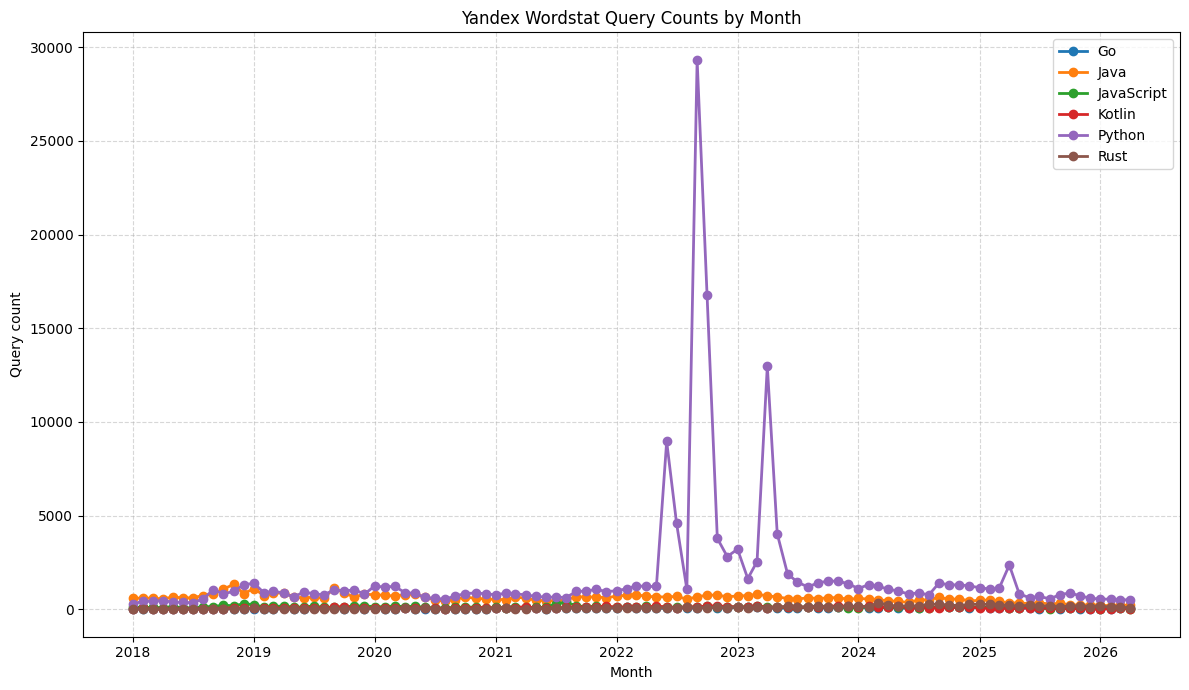

In [8]:
plt.figure(figsize=(12, 7))

for language in monthly_index_df["language"].unique():
    language_df = monthly_index_df[monthly_index_df["language"] == language]
    plt.plot(language_df["date"], language_df["count"], marker="o", linewidth=2, label=language)

plt.title("Yandex Wordstat Query Counts by Month")
plt.xlabel("Month")
plt.ylabel("Query count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 10. График долей интереса

Здесь показана доля каждого языка в общем интересе к выбранным языкам после нормализации относительно Java.

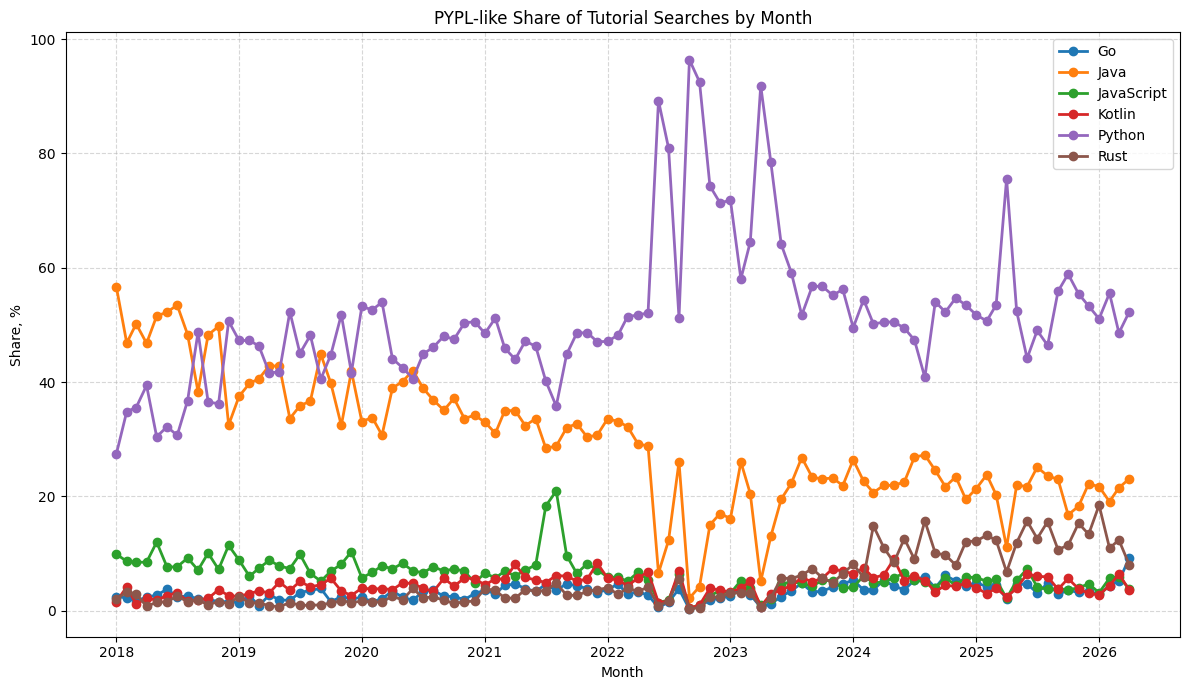

In [9]:
plt.figure(figsize=(12, 7))

for language in monthly_index_df["language"].unique():
    language_df = monthly_index_df[monthly_index_df["language"] == language]
    plt.plot(language_df["date"], language_df["share_pct"], marker="o", linewidth=2, label=language)

plt.title("PYPL-like Share of Tutorial Searches by Month")
plt.xlabel("Month")
plt.ylabel("Share, %")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Сглаженные доли интереса

Сглаживание 6-месячным средним помогает убрать слишком резкие колебания и лучше увидеть общий тренд.

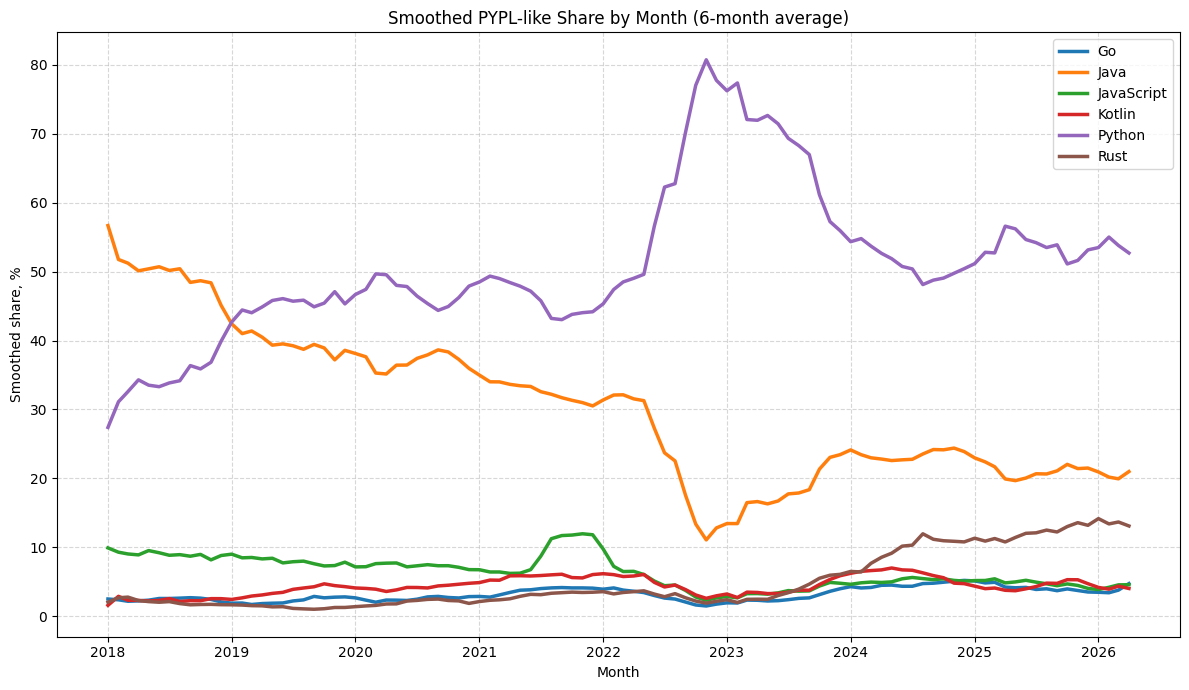

In [10]:
plt.figure(figsize=(12, 7))

for language in monthly_index_df["language"].unique():
    language_df = monthly_index_df[monthly_index_df["language"] == language]
    plt.plot(language_df["date"], language_df["smoothed_share_pct"], linewidth=2.5, label=language)

plt.title("Smoothed PYPL-like Share by Month (6-month average)")
plt.xlabel("Month")
plt.ylabel("Smoothed share, %")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Сравнение языков по последнему месяцу

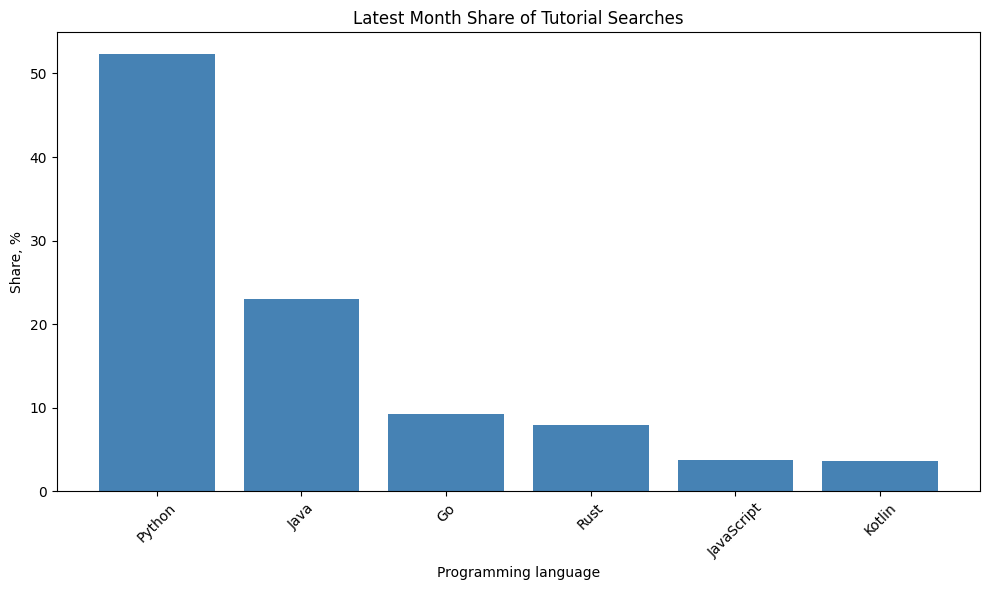

In [11]:
plt.figure(figsize=(10, 6))
plt.bar(latest_ranking_df["language"], latest_ranking_df["share_pct"], color="steelblue")
plt.title("Latest Month Share of Tutorial Searches")
plt.xlabel("Programming language")
plt.ylabel("Share, %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Сравнение языков по годовому тренду

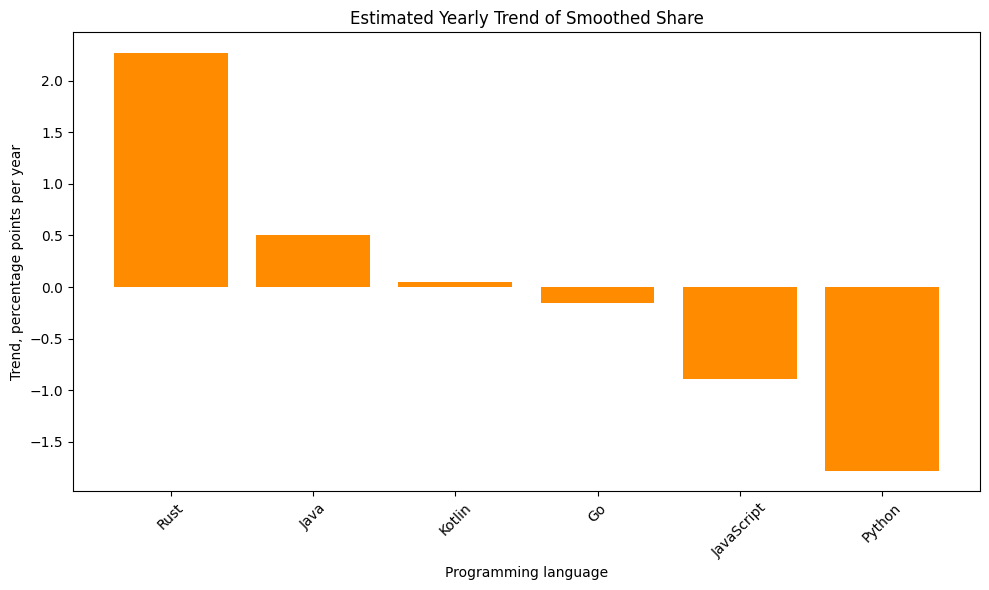

In [12]:
trend_df = latest_ranking_df.sort_values("yearly_trend_pp", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(trend_df["language"], trend_df["yearly_trend_pp"], color="darkorange")
plt.title("Estimated Yearly Trend of Smoothed Share")
plt.xlabel("Programming language")
plt.ylabel("Trend, percentage points per year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Основные выводы

Формируем краткие выводы по последнему месяцу и по всему периоду наблюдений.

In [13]:
latest_month = latest_ranking_df["date"].max()
leader_row = latest_ranking_df.loc[latest_ranking_df["share_pct"].idxmax()]
growth_row = latest_ranking_df.loc[latest_ranking_df["yearly_trend_pp"].idxmax()]
average_row = latest_ranking_df.loc[latest_ranking_df["average_share_pct"].idxmax()]

print("Краткие выводы:")
print(f"- Последний месяц в выборке: {latest_month.date()}")
print(f"- Лидер по доле поискового интереса: {leader_row['language']} ({leader_row['share_pct']:.2f}%)")
print(f"- Самый сильный годовой рост показывает: {growth_row['language']} ({growth_row['yearly_trend_pp']:.2f} п.п. в год)")
print(f"- Самая высокая средняя доля за весь период у языка: {average_row['language']} ({average_row['average_share_pct']:.2f}%)")
print("- Это PYPL-like исследование на данных Yandex Wordstat, а не официальный индекс PYPL.")
print("- Результаты чувствительны к выбранным tutorial-запросам.")

Краткие выводы:
- Последний месяц в выборке: 2026-04-01
- Лидер по доле поискового интереса: Python (52.31%)
- Самый сильный годовой рост показывает: Rust (2.26 п.п. в год)
- Самая высокая средняя доля за весь период у языка: Python (51.42%)
- Это PYPL-like исследование на данных Yandex Wordstat, а не официальный индекс PYPL.
- Результаты чувствительны к выбранным tutorial-запросам.
